## Setup

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import optuna
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix

from csi_vae.jobs import JobSettings, dataset, vae, fusion
from csi_vae.jobs.job import make_dataloader

plt.style.use("seaborn-v0_8-paper")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "figure.dpi": 300,
})

settings = JobSettings()

LAUNCH_DIR = Path("../out/flat_conv_full")
PLOTS_DIR = LAUNCH_DIR / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ACTIVITIES = [
    "Walk",
    "Run",
    "Jump",
    "Sit",
    "Empty",
    "Stand",
    "Waving",
    "Clap",
    "Lay down",
    "Wipe",
    "Squat",
    "Stretch",
]

/mnt/servicesdata/lcotti/csi-vae/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Best Model

In [ ]:
studies_files = sorted([f.name for f in LAUNCH_DIR.iterdir() if f.is_file() and f.suffix == ".sqlite"])
studies = [
    optuna.load_study(study_name=study.split(".")[0], storage=f"sqlite:///{LAUNCH_DIR / study}").trials_dataframe()
    for study in studies_files
]

In [ ]:
best_model: tuple[int, int, int, float] = (1, 0, 0, 0.0)  # (n_gaussians, trial_number, seed, accuracy)
best_trial = {}

for i, study in enumerate(studies):
    completed = study[study["state"] == "COMPLETE"].copy()
    if completed.empty:
        continue

    study_best: tuple[int, int, int, float] = (0, 0, 0, 0.0)

    for _, trial in completed.iterrows():
        acc_dict = trial["user_attrs_accuracies"]
        if not acc_dict:
            continue

        seed = str(max(acc_dict, key=acc_dict.get))
        acc = float(acc_dict[seed])
        candidate = (i+1, int(trial["number"]), int(seed), acc)

        if candidate[-1] > study_best[-1]:
            study_best = candidate

        if candidate[-1] > best_model[-1]:
            best_model = candidate
            best_n_gaussians = i + 1
            best_trial = trial

print(f"Best model: {best_model[0]} gaussians, trial {best_model[1]}, seed {best_model[2]}, accuracy {best_model[3]:.4f}")
print(f"Best trial: {best_trial}")


Best model: 2 gaussians, trial 21, seed 420148083, accuracy 0.9833
Best trial: number                                                                    21
value                                                               0.953125
datetime_start                                    2026-03-28 17:16:32.904193
datetime_complete                                 2026-03-28 17:31:46.850169
duration                                              0 days 00:15:13.945976
params_batch_size_exp                                                      5
params_conv_layers_spec                                                    0
params_fusion_dropout                                                    0.3
params_kl_max                                                       6.532326
params_lr                                                            0.00715
params_n_fusion_layers                                                     1
user_attrs_accuracies      {'347227206': 0.9125, '420148083': 0.983333333.

In [ ]:
full_train_ds, full_val_ds, full_test_ds = dataset.load(
    dataset_path=Path("../") / settings.dataset_path,
    window_size=settings.window_size,
    n_activities=settings.n_activities,
    stride=settings.stride,
)

gaussians = [vae.SingleAntenna(settings.window_size, settings.n_subcarriers, best_model[0], vae.CONV_SPECS[best_trial["params_conv_layers_spec"]]).to(DEVICE) for _ in range(settings.n_antennas)]
model = fusion.Delayed(gaussians, settings.n_gaussians, settings.n_activities, best_trial["params_n_fusion_layers"], best_trial["params_fusion_dropout"]).to(DEVICE)
model.load_state_dict(torch.load(LAUNCH_DIR / "delayed_fusion.pt"))

<All keys matched successfully>

## t-SNE

In [ ]:
full_ds = torch.utils.data.ConcatDataset([full_train_ds, full_val_ds, full_test_ds])
full_dl = make_dataloader(full_ds, settings.batch_size, shuffle=False, seed=best_model[2])

all_latents, all_labels = [], []

for antenna_idx, gaussian in enumerate(gaussians):
    antenna_latents, antenna_labels = [], []

    gaussian.eval().to(DEVICE)
    for x, y in full_dl:
        with torch.no_grad():
            x_antenna = x[:, antenna_idx].to(DEVICE, dtype=torch.float32)
            mu, logvar = gaussian.encode(x_antenna)

            antenna_latents.append(torch.cat([mu, logvar], dim=1).cpu().numpy())
            antenna_labels.append(y.numpy())

    all_latents.append(np.concatenate(antenna_latents))
    all_labels.append(np.concatenate(antenna_labels))

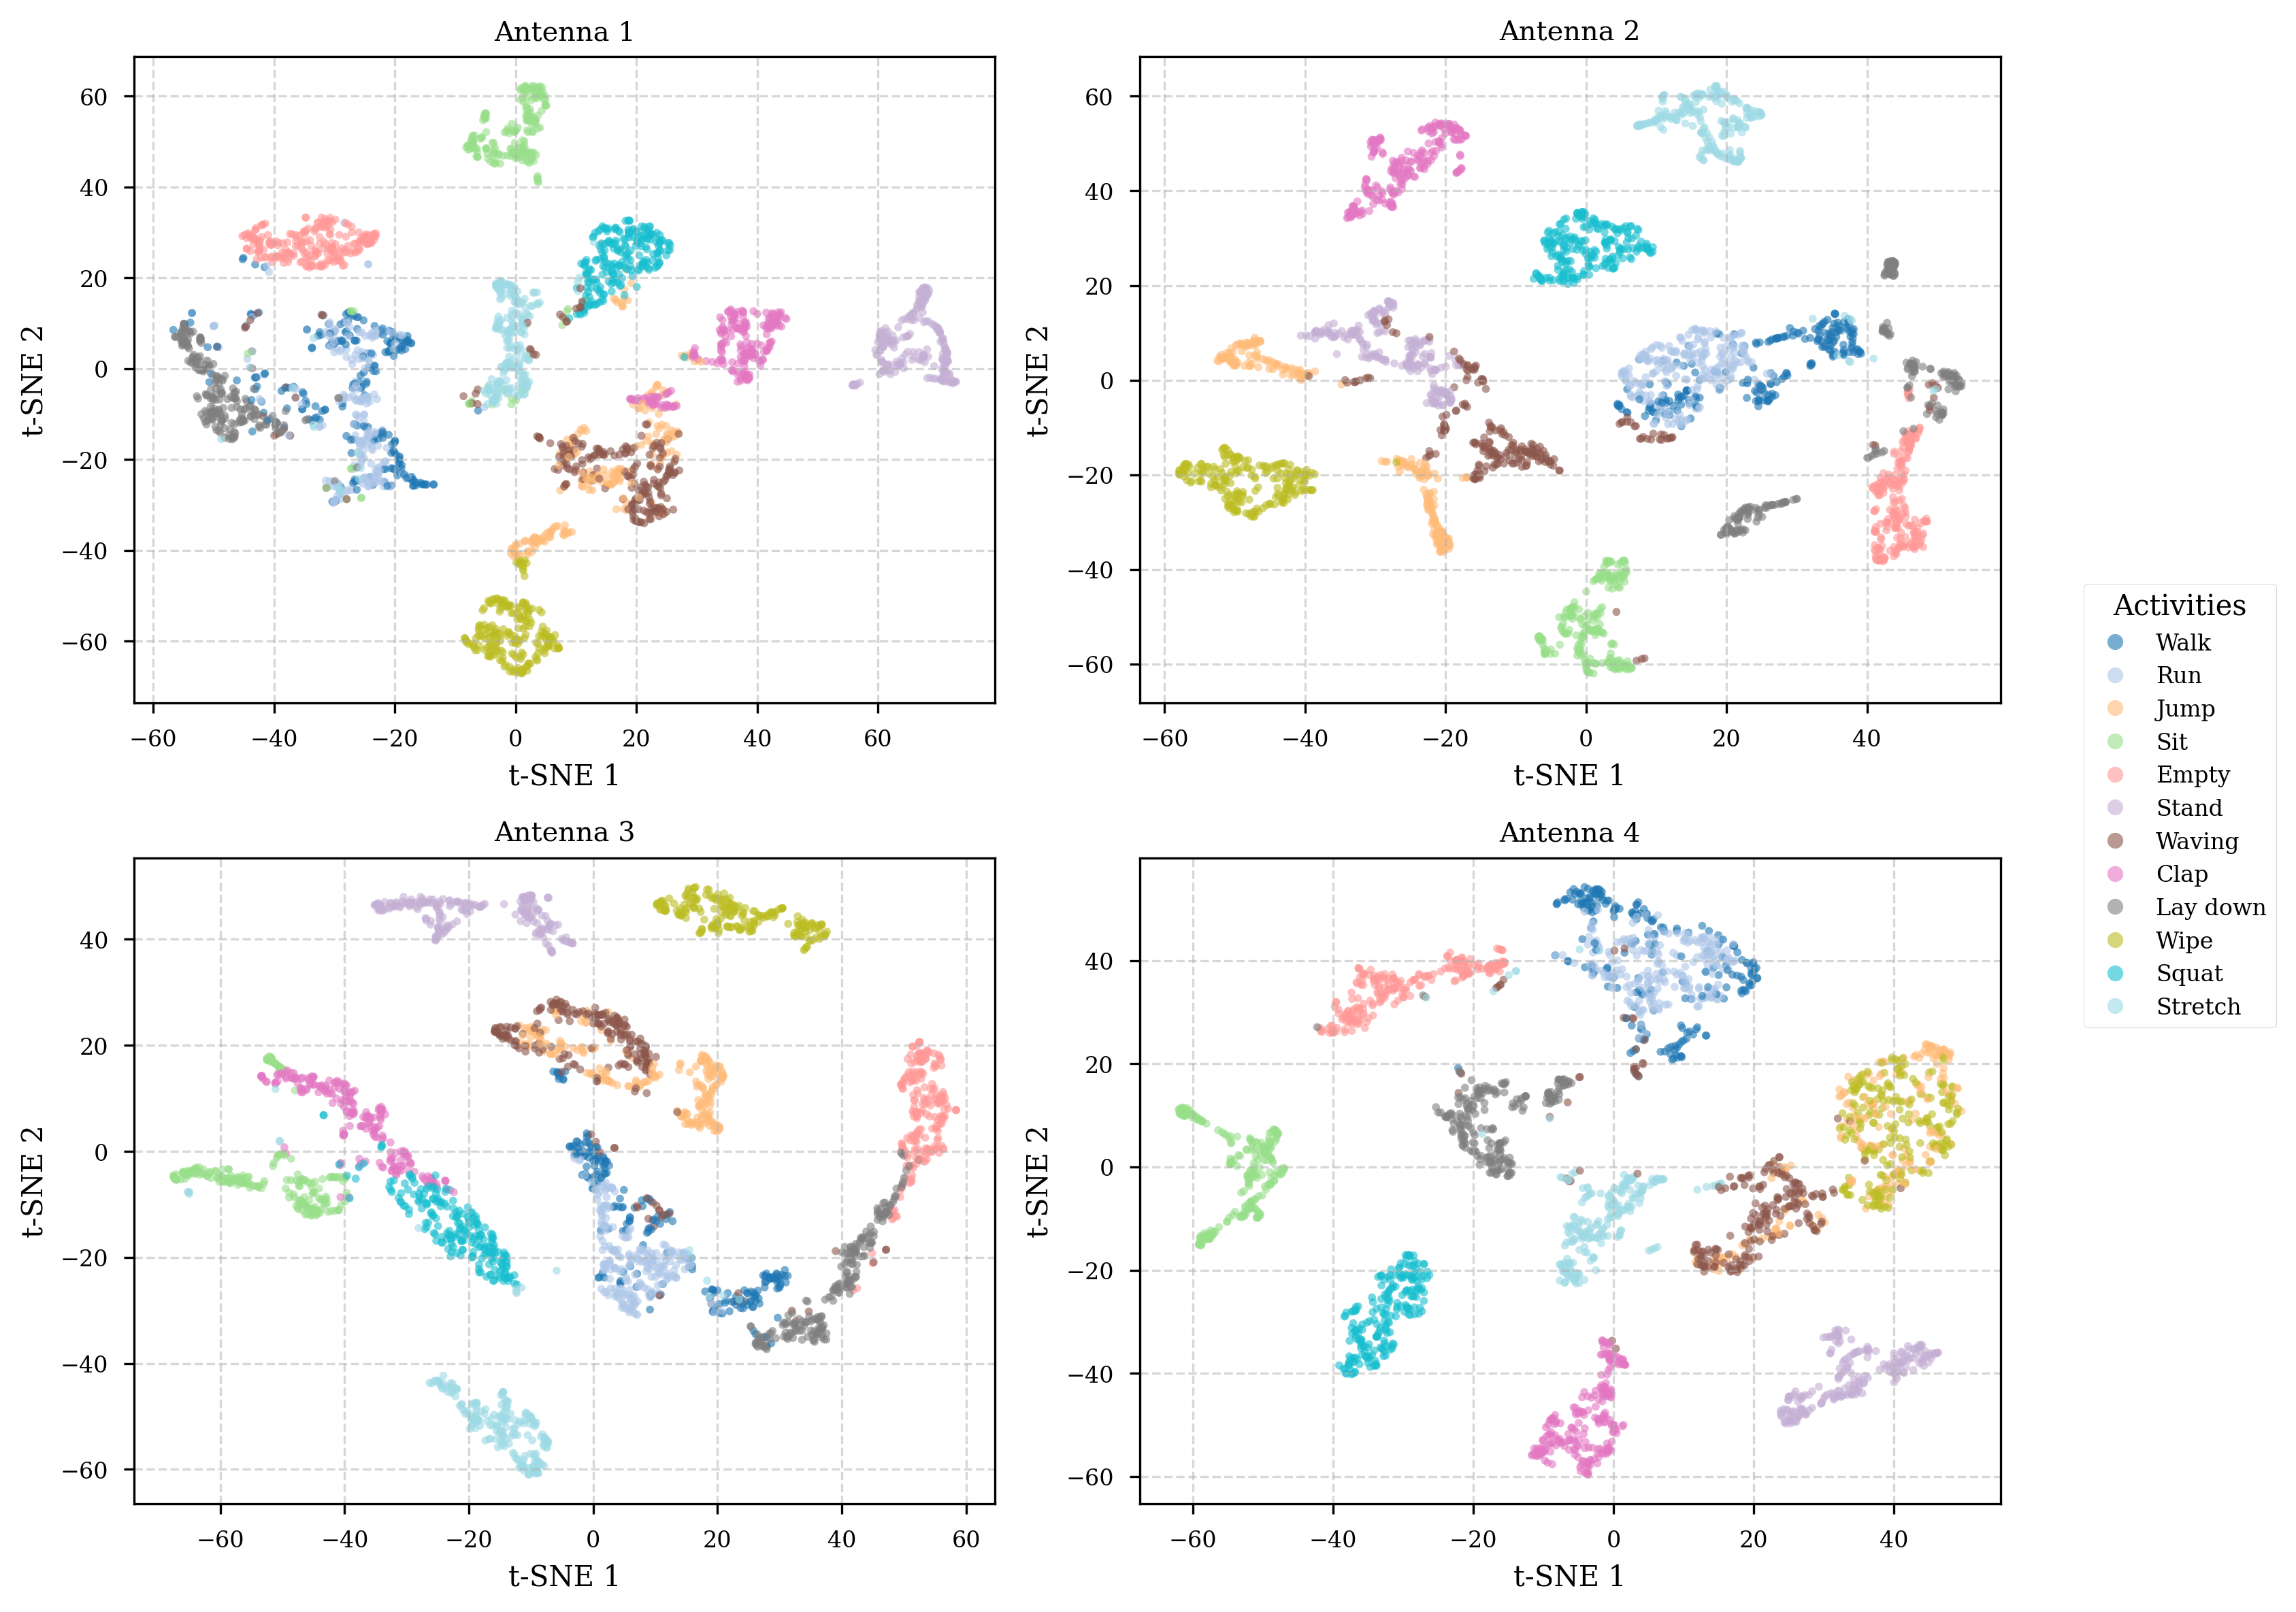

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

last_scatter = None

for antenna_idx, (latents, labels) in enumerate(zip(all_latents, all_labels, strict=True)):
    tsne = TSNE(
        n_components=2,
        random_state=best_model[2],
        perplexity=30,
    ).fit_transform(latents)

    ax = axes[antenna_idx]
    last_scatter = ax.scatter(
        tsne[:, 0],
        tsne[:, 1],
        c=labels,
        cmap="tab20",
        alpha=0.6,
        edgecolor="w",
        s=8,
        linewidths=0,
        vmin=0,
        vmax=len(ACTIVITIES) - 1,
    )

    ax.set_title(f"Antenna {antenna_idx + 1}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.grid(True, linestyle="--", alpha=0.5)

handles, _ = last_scatter.legend_elements(prop="colors", num=len(ACTIVITIES)) # pyright: ignore[reportOptionalMemberAccess]
fig.legend(
    handles,
    ACTIVITIES,
    title="Activities",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "best_tsne_gaussians.pdf", bbox_inches="tight")
plt.show()

## Confusion Matrix

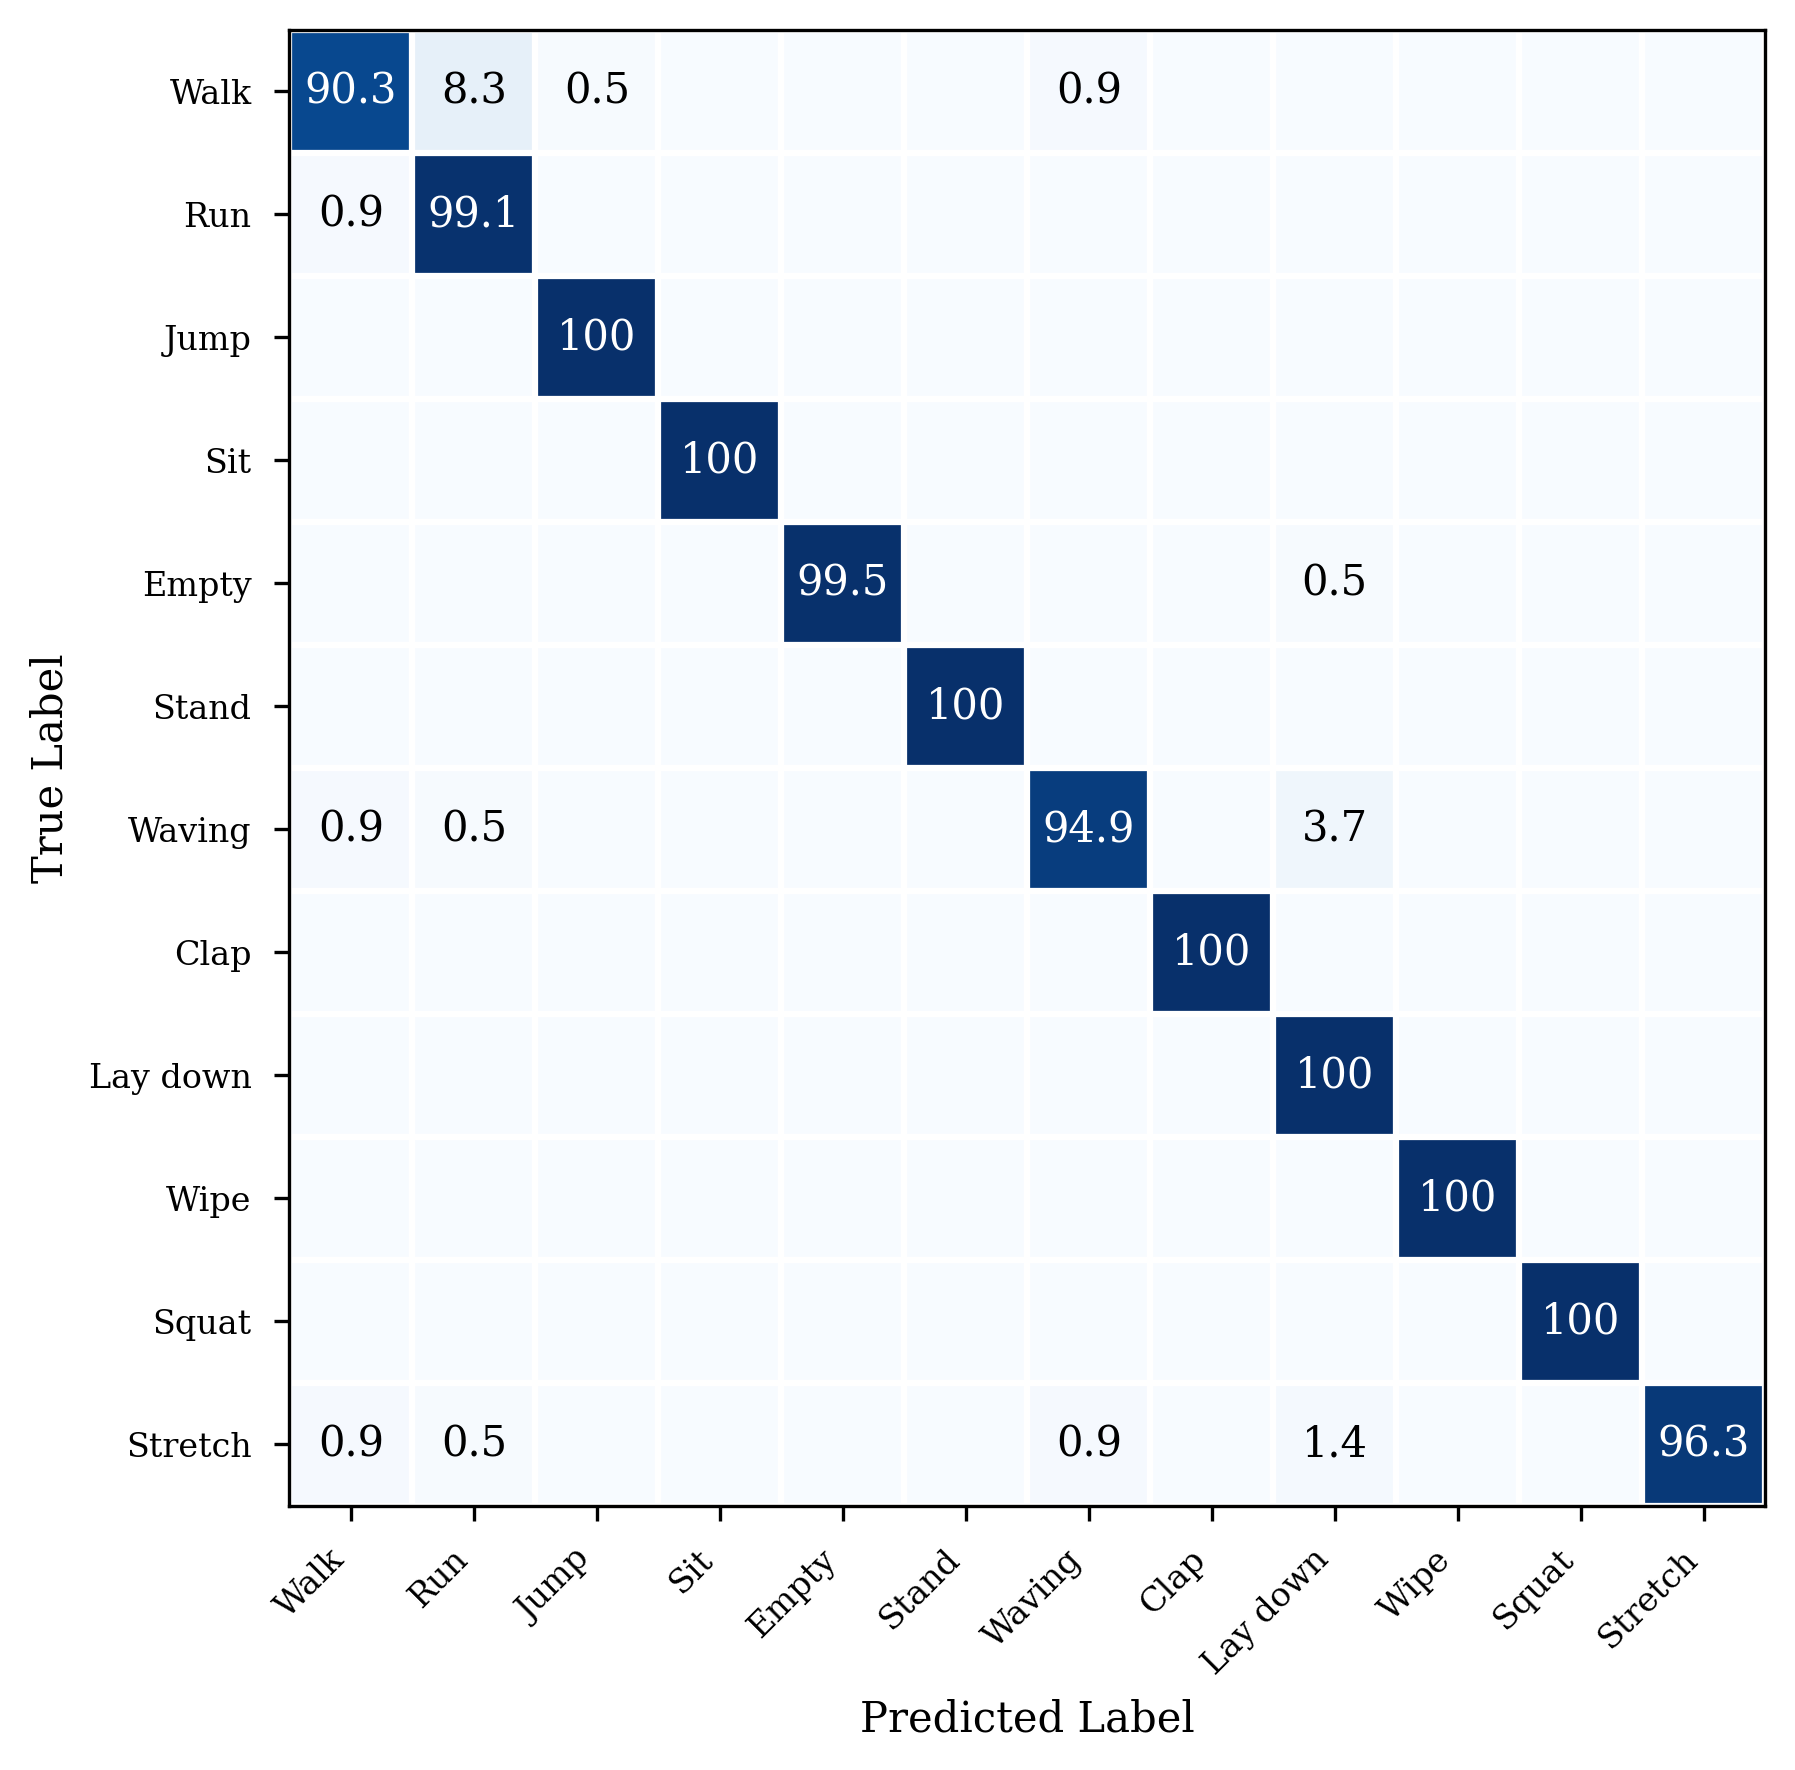

In [ ]:
y_preds, y_trues = [], []
for x, y in full_dl:
    with torch.no_grad():
        y_pred = model(x.to(DEVICE, dtype=torch.float32))
        y_preds.append(y_pred.cpu().numpy())
        y_trues.append(y.numpy())

cm = confusion_matrix(
    np.concatenate(y_trues),
    np.concatenate(y_preds).argmax(axis=1),
)

plt.figure(figsize=(8, 6))
# Normalize by row (True Labels) to see percentages
matrix_perc = cm.astype("float") / (cm.sum(axis=1)[:, np.newaxis] + 1e-12)

im = plt.imshow(matrix_perc, cmap="Blues")

thresh = matrix_perc.max() / 2
for i in range(len(ACTIVITIES)):
    for j in range(len(ACTIVITIES)):
        if cm[i, j] == 0:
            continue  # Skip zero counts for better readability

        color = "white" if matrix_perc[i, j] > thresh else "black"
        text = f"{matrix_perc[i, j] * 100:.1f}".rstrip("0").rstrip(".")
        plt.text(j, i, text, ha="center", va="center", color=color)

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.xticks(rotation=45, ha="right", ticks=np.arange(len(ACTIVITIES)), labels=ACTIVITIES)
plt.yticks(rotation=0, ticks=np.arange(len(ACTIVITIES)), labels=ACTIVITIES)

ax = plt.gca()
ax.set_xticks(np.arange(-0.5, len(ACTIVITIES)), minor=True)
ax.set_yticks(np.arange(-0.5, len(ACTIVITIES)), minor=True)
ax.grid(which="minor", color="white", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)

# plt.colorbar(im, fraction=0.046, pad=0.04, label="Percentage (%)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "best_confusion_matrix_gaussians.pdf", bbox_inches="tight")
plt.show()